# Graph Convolutional Network

- [ ] Найти графовый набор данных для решения задачи предсказания (классификация вершин, обнаружение сообществ и т.д.).
- [ ] Использовать несколько слоев `GCNConv` из библиотеки `PyG` для построения GCN модели.
- [ ] Обучить полученную модель, подобрать гиперпараметры (например, learning rate) на валидационной выборке, и оценить качество предсказания на тестовой выборке.
- [ ] (+5 баллов) Также представить самостоятельную реализацию слоя `GCNConv`, используя матричные операции. Повторить обучение с собственными слоями и сравнить результаты.

## Импорты

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.transforms import NormalizeFeatures
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import add_self_loops, degree

## Датасет

В качестве датасета был выбран Cora - классический датасет для задач классификации вершин в графах. Он состоит из научных публикаций, связанных цитатами между собой. Каждая вершина графа соответствует публикации, а каждое ребро — факту цитирования одной статьи другой. Признаки вершины — это мешок слов (bag-of-words), отражающий содержимое статьи. Задача заключается в предсказании тематики (одного из 7 классов) статьи на основе ее содержимого и структуры графа.

In [4]:
torch.manual_seed(42)

dataset = Planetoid(root='datasets/Cora', name='Cora', transform=NormalizeFeatures())
graph_data = dataset[0]

Processing...
Done!


In [5]:
print(f"Число признаков на вершину: {dataset.num_features}")
print(f"Число классов: {dataset.num_classes}")
print(f"Число вершин: {graph_data.num_nodes}")
print(f"Число рёбер: {graph_data.num_edges}")
print(f"Доля обучающей выборки: {graph_data.train_mask.sum().item()} узлов")
print(f"Доля валидации: {graph_data.val_mask.sum().item()} узлов")
print(f"Доля тестовой выборки: {graph_data.test_mask.sum().item()} узлов")
print(f"Наличие самосвязей (self-loops): {graph_data.has_self_loops()}")
print(f"Граф ориентированный? {'Да' if graph_data.is_directed() else 'Нет'}")

Число признаков на вершину: 1433
Число классов: 7
Число вершин: 2708
Число рёбер: 10556
Доля обучающей выборки: 140 узлов
Доля валидации: 500 узлов
Доля тестовой выборки: 1000 узлов
Наличие самосвязей (self-loops): False
Граф ориентированный? Нет


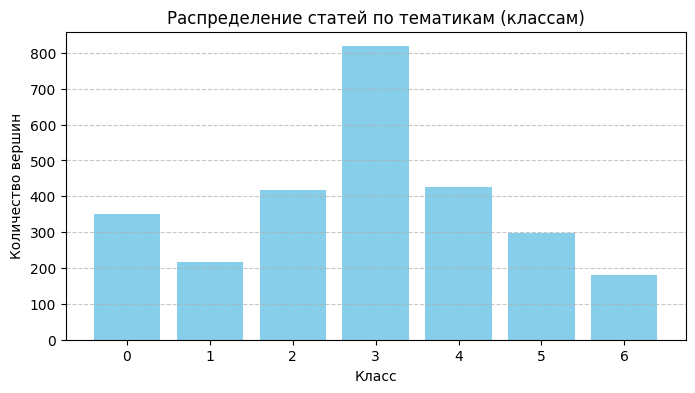

In [6]:
labels = graph_data.y.numpy()
classes, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(classes, counts, color="skyblue")
plt.xticks(classes)
plt.title("Распределение статей по тематикам (классам)")
plt.xlabel("Класс")
plt.ylabel("Количество вершин")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## GCN модель

In [13]:
class GraphConvolutionNetwork(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_rate=0.5):
        super(GraphConvolutionNetwork, self).__init__()
        self.layer1 = GCNConv(in_channels, hidden_channels)
        self.layer2 = GCNConv(hidden_channels, out_channels)
        self.dropout_rate = dropout_rate

    def forward(self, features, edges):
        x = self.layer1(features, edges)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.layer2(x, edges)
        return F.log_softmax(x, dim=1)


In [14]:
model = GraphConvolutionNetwork(dataset.num_features, 16, dataset.num_classes)

optm = torch.optim.Adam(params=model.parameters(), lr=0.01, weight_decay=5e-4)

In [15]:
class Trainer:
    def __init__(self, model, optimizer, data):
        self.model = model
        self.optimizer = optimizer
        self.data = data

    def train_epoch(self):
        self.model.train()
        self.optimizer.zero_grad()
        out = self.model(self.data.x, self.data.edge_index)
        loss = F.nll_loss(out[self.data.train_mask], self.data.y[self.data.train_mask])
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def evaluate(self, mask):
        self.model.eval()
        with torch.no_grad():
            out = self.model(self.data.x, self.data.edge_index)
            pred = out.argmax(dim=1)
            correct = (pred[mask] == self.data.y[mask]).sum().item()
            total = mask.sum().item()
            accuracy = correct / total if total > 0 else 0
        return accuracy

In [30]:
best_val_accuracy = 0.0
best_learning_rate = 0.01
trainer = Trainer(model, optm, graph_data)

learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:
    print(f"\n=== Training with learning rate: {lr} ===")
    trainer.optimizer.param_groups[0]['lr'] = lr
    
    for epoch in range(1, 201):
        loss = trainer.train_epoch()
        if epoch % 50 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")
    
    val_accuracy = trainer.evaluate(graph_data.val_mask)
    print(f"Validation accuracy with lr={lr}: {val_accuracy:.4f}")
    
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_learning_rate = lr
    
    print(f"Current best lr: {best_learning_rate} with validation accuracy: {best_val_accuracy:.4f}")

print(f"\nBest validation accuracy overall: {best_val_accuracy:.4f} achieved at lr={best_learning_rate}")

trainer.optimizer.param_groups[0]['lr'] = best_learning_rate
print(f"\n=== Final training with best lr: {best_learning_rate} ===")

for epoch in range(1, 201):
    loss = trainer.train_epoch()
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

test_accuracy = trainer.evaluate(graph_data.test_mask)
print(f"\nTest Accuracy: {test_accuracy:.4f}")



=== Training with learning rate: 0.1 ===
Epoch 001 | Loss: 0.1842
Epoch 050 | Loss: 0.1990
Epoch 100 | Loss: 0.2037
Epoch 150 | Loss: 0.2337
Epoch 200 | Loss: 0.2071
Validation accuracy with lr=0.1: 0.7800
Current best lr: 0.1 with validation accuracy: 0.7800

=== Training with learning rate: 0.01 ===
Epoch 001 | Loss: 0.1979
Epoch 050 | Loss: 0.1822
Epoch 100 | Loss: 0.1880
Epoch 150 | Loss: 0.1955
Epoch 200 | Loss: 0.2125
Validation accuracy with lr=0.01: 0.7960
Current best lr: 0.01 with validation accuracy: 0.7960

=== Training with learning rate: 0.001 ===
Epoch 001 | Loss: 0.1766
Epoch 050 | Loss: 0.1740
Epoch 100 | Loss: 0.1894
Epoch 150 | Loss: 0.1979
Epoch 200 | Loss: 0.1606
Validation accuracy with lr=0.001: 0.7940
Current best lr: 0.01 with validation accuracy: 0.7960

Best validation accuracy overall: 0.7960 achieved at lr=0.01

=== Final training with best lr: 0.01 ===
Epoch 001 | Loss: 0.2017
Epoch 050 | Loss: 0.1905
Epoch 100 | Loss: 0.1729
Epoch 150 | Loss: 0.1642
Epoc

## Кастомная реализация

In [ ]:
class CustomGCNLayer(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = torch.nn.Linear(in_features, out_features, bias=False)
        self.bias = torch.nn.Parameter(torch.zeros(out_features))
        self.reset_parameters()

    def reset_parameters(self):
        self.linear.reset_parameters()
        with torch.no_grad():
            self.bias.fill_(0)

    def forward(self, x, edge_index):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))
        src_nodes, tgt_nodes = edge_index

        deg = degree(src_nodes, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)

        norm = deg_inv_sqrt[src_nodes] * deg_inv_sqrt[tgt_nodes]

        adj = torch.sparse_coo_tensor(edge_index, norm, (x.size(0), x.size(0)))

        x = torch.sparse.mm(adj, x)
        x = self.linear(x)
        x = x + self.bias
        return x


In [26]:
class CustomGCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.5):
        super().__init__()
        self.layer1 = CustomGCNLayer(input_dim, hidden_dim)
        self.layer2 = CustomGCNLayer(hidden_dim, output_dim)
        self.dropout = torch.nn.Dropout(p=dropout_rate)

    def forward(self, x, edge_index):
        x = self.layer1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.layer2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [27]:
model = CustomGCN(dataset.num_features, 16, dataset.num_classes)

optm = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

In [29]:
best_val_acc = 0.0
best_lr = 0.01

for lr in [0.1, 0.01, 0.001]:
    optm.param_groups[0]['lr'] = lr
    print(f"\n*** Training with learning rate: {lr} ***")
    
    for epoch in range(1, 201):
        model.train()
        optm.zero_grad()
        out = model(graph_data.x, graph_data.edge_index)
        loss = F.nll_loss(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
        loss.backward()
        optm.step()
        
        if epoch == 1 or epoch % 50 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
    
    model.eval()
    with torch.no_grad():
        output = model(graph_data.x, graph_data.edge_index)
        preds = output.argmax(dim=1)
        val_correct = (preds[graph_data.val_mask] == graph_data.y[graph_data.val_mask]).sum().item()
        val_total = graph_data.val_mask.sum().item()
        val_acc = val_correct / val_total

    print(f"Validation accuracy with lr={lr}: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_lr = lr
        print(f"New best learning rate found: {best_lr} with val accuracy: {best_val_acc:.4f}")

print(f"\nTraining final model with best learning rate: {best_lr}")
optm.param_groups[0]['lr'] = best_lr

for epoch in range(1, 201):
    model.train()
    optm.zero_grad()
    out = model(graph_data.x, graph_data.edge_index)
    loss = F.nll_loss(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
    loss.backward()
    optm.step()
    
    if epoch == 1 or epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

model.eval()
with torch.no_grad():
    output = model(graph_data.x, graph_data.edge_index)
    preds = output.argmax(dim=1)
    test_correct = (preds[graph_data.test_mask] == graph_data.y[graph_data.test_mask]).sum().item()
    test_total = graph_data.test_mask.sum().item()
    test_acc = test_correct / test_total

print(f"\nTest Accuracy (custom GCN): {test_acc:.4f}")


*** Training with learning rate: 0.1 ***
Epoch 001 | Loss: 0.1937
Epoch 050 | Loss: 0.2241
Epoch 100 | Loss: 0.2020
Epoch 150 | Loss: 0.2396
Epoch 200 | Loss: 0.2180
Validation accuracy with lr=0.1: 0.7820
New best learning rate found: 0.1 with val accuracy: 0.7820

*** Training with learning rate: 0.01 ***
Epoch 001 | Loss: 0.1855
Epoch 050 | Loss: 0.1950
Epoch 100 | Loss: 0.1854
Epoch 150 | Loss: 0.1958
Epoch 200 | Loss: 0.1787
Validation accuracy with lr=0.01: 0.7940
New best learning rate found: 0.01 with val accuracy: 0.7940

*** Training with learning rate: 0.001 ***
Epoch 001 | Loss: 0.1865
Epoch 050 | Loss: 0.1764
Epoch 100 | Loss: 0.1969
Epoch 150 | Loss: 0.1948
Epoch 200 | Loss: 0.1837
Validation accuracy with lr=0.001: 0.7920

Training final model with best learning rate: 0.01
Epoch 001 | Loss: 0.1944
Epoch 050 | Loss: 0.2089
Epoch 100 | Loss: 0.2140
Epoch 150 | Loss: 0.1860
Epoch 200 | Loss: 0.2128

Test Accuracy (custom GCN): 0.8110


## Результат

Первая, базовая реализация достигла точности около 0.8100, в то время как кастомная модель — 0.8110.

Из полученных результатов видно, что обе модели демонстрируют очень схожую точность на тестовой выборке, что подтверждает правильность и эффективность самостоятельной реализации.